# LOADING DATASET AND RELEVANT LIBRARIES


In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
# Loading the dataset
df=pd.read_csv('mobile_sales_data.csv')
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


# DATA CLEANING




In [4]:
# Gathering a summary of the data to understand the data types , no. of non-nulls etc
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-null  object
 6   Dispatch Date            50000 non-null  object
 7   Quantity Sold            50000 non-null  int64 
 8   Customer Name            50000 non-null  object
 9   Customer Location        50000 non-null  object
 10  Region                   50000 non-null  object
 11  Core Specification       25017 non-null  object
 12  Processor Specification  50000 non-null  object
 13  RAM                      50000 non-null  object
 14  ROM                      50000 non-nul

In [5]:
#finding the no. of null values in each column
df.isnull().sum() 

#THEORY:
    #nulls in core specification and SSD columns
    #are from the mobile phones 
    #as they have neither a core nor an SSD 



Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64

In [6]:
# PROVING MY THEORY:

#a. Checking the product breakdown for rows where SSD values are missing
print("Product with missing SSD values:")
print(df[df['SSD'].isnull()]['Product'].value_counts())

#b. Checking the product breakdown for rows where Core specification values are missing
print("Product with missing Core values:")
print(df[df['Core Specification'].isnull()]['Product'].value_counts())

Product with missing SSD values:
Product
Mobile Phone    24983
Name: count, dtype: int64
Product with missing Core values:
Product
Mobile Phone    24983
Name: count, dtype: int64


In [7]:
# filling in Nulls
df['Core Specification']=df['Core Specification'].fillna('None')
df['SSD']=df['SSD'].fillna('None')

#checking no.of nulls again
print(df.isnull().sum())

Product                    0
Brand                      0
Product Code               0
Product Specification      0
Price                      0
Inward Date                0
Dispatch Date              0
Quantity Sold              0
Customer Name              0
Customer Location          0
Region                     0
Core Specification         0
Processor Specification    0
RAM                        0
ROM                        0
SSD                        0
dtype: int64


In [8]:
#check for duplicates
print(df.duplicated().sum())

0


# DATA ANALYSIS

In [9]:
#insight on the distribution of data
df.describe()

,Price,Quantity Sold
count,50000.000000,50000.00000
mean,102641.407080,5.51378
std,56363.550361,2.88101
min,5008.000000,1.00000
25%,53487.000000,3.00000
50%,103072.000000,6.00000
75%,151396.250000,8.00000
max,199999.000000,10.00000


HIGHEST SELLING BRANDS BY QTY

In [10]:
# Top selling Product
top_product=df.groupby('Product')['Quantity Sold'].sum().sort_values(ascending=False)
print(top_product)

Product
Laptop          138019
Mobile Phone    137670
Name: Quantity Sold, dtype: int64


In [11]:
# Finding the Qty sold by each brand 
# Highest selling brands according to Quantity
brand_byqty =df.groupby(['Brand'])['Quantity Sold'].sum().sort_values(ascending=False).head(10)
print(brand_byqty)
# Finding the mean prices of the highest selling brands
# To help determine whether or not qty sold is determined by Price
print('\n \nMEAN PRICES OF THE TOP 10 SELLING BRANDS:')
mean_prices=df.groupby('Brand')['Price'].mean().nlargest(10).round(2)
print(mean_prices)

Brand
Google      14412
Nokia       14239
Apple       14197
Sony        14043
Samsung     14033
Toshiba     13996
Redmi       13948
Motorola    13888
OnePlus     13880
Acer        13854
Name: Quantity Sold, dtype: int64

 
MEAN PRICES OF THE TOP 10 SELLING BRANDS:
Brand
Nokia        104432.58
Google       104308.97
Toshiba      104224.78
Microsoft    103841.41
Apple        103728.83
Dell         103548.64
Samsung      103383.02
Redmi        102836.59
Motorola     102728.75
Lenovo       102576.93
Name: Price, dtype: float64


HIGHEST SELLING BRANDS BY REVENUE


In [12]:
# Calculating revenue
df['Revenue']=df['Price'] * df['Quantity Sold'] # Create a revenue column in the Dataset

#Reviewing the Revenue column
print(df['Revenue'])

0         471420
1          44613
2         799130
3          20911
4         279328
          ...   
49995    1022310
49996     772532
49997     399012
49998     317766
49999     605381
Name: Revenue, Length: 50000, dtype: int64


In [13]:
# Highest selling Product according to Revenue
df.groupby('Product')['Revenue'].sum()

Product
Laptop          14187414822
Mobile Phone    14091666300
Name: Revenue, dtype: int64

In [14]:
# Highest selling brands according to Revenue
highest_selling_brands=df.groupby('Brand')['Revenue'].sum().sort_values(ascending=False).head(5)
print(highest_selling_brands)

Brand
Google     1514617084
Nokia      1473167125
Apple      1470242666
Toshiba    1454585835
Sony       1442582351
Name: Revenue, dtype: int64


ANALYZING SELLING PATTERNS ACCORDING TO REGIONS


In [15]:
# Highest selling regions according to qty
df.groupby('Region')['Quantity Sold'].sum().sort_values(ascending=False)

Region
West       56602
South      55214
North      55035
East       54745
Central    54093
Name: Quantity Sold, dtype: int64

In [16]:
# Highest selling regions according to revenue and Qty
top_product_region=df.groupby(['Region','Product'])['Quantity Sold'].sum().reset_index()

top_product_region=top_product_region.loc[
    top_product_region.groupby('Region')['Quantity Sold'].idxmax()
]
print(top_product_region)

    Region       Product  Quantity Sold
1  Central  Mobile Phone          27546
2     East        Laptop          27499
4    North        Laptop          27711
6    South        Laptop          27667
8     West        Laptop          28595


In [17]:
# Highest selling regions according to brand and qty
top_brand_region= df.groupby(['Region','Brand'])['Quantity Sold'].sum().reset_index()

top_brand_region=top_brand_region.loc[
    top_brand_region.groupby('Region')['Quantity Sold'].idxmax()
]
print(top_brand_region)

     Region   Brand  Quantity Sold
5   Central      HP           2996
30     East   Nokia           2992
46    North  Huawei           2925
61    South   Apple           2933
81     West   Apple           3099


In [18]:
# FINDING THE TOP PERFORMING BRAND AND PRODUCT ACCORDING TO REVENUE

#1. start of by groupping by geion,brand and product
brand_region_revenue = df.groupby(['Region', 'Brand','Product'])['Revenue'].sum().reset_index()

top_brand_region = brand_region_revenue.loc[

#2. Picking row with the highest revenue per region
    brand_region_revenue.groupby('Region')['Revenue'].idxmax()
]
print(top_brand_region)

      Region   Brand       Product    Revenue
11   Central      HP  Mobile Phone  164950445
42      East   Apple        Laptop  165323133
82     North   Apple        Laptop  161200879
148    South   Redmi        Laptop  163879926
168     West  Google        Laptop  169206337


In [19]:
Customer_summary = df.groupby('Customer Name').agg({
    'Quantity Sold': 'sum',
    'Revenue': 'sum'
}).reset_index()

#Getting the top customer
top_customer = Customer_summary.sort_values(by='Quantity Sold', ascending=False).iloc[0]

print(top_customer)

Customer Name    Robert Smith
Quantity Sold             117
Revenue              11477343
Name: 32438, dtype: object


# VISUALIZATIONS

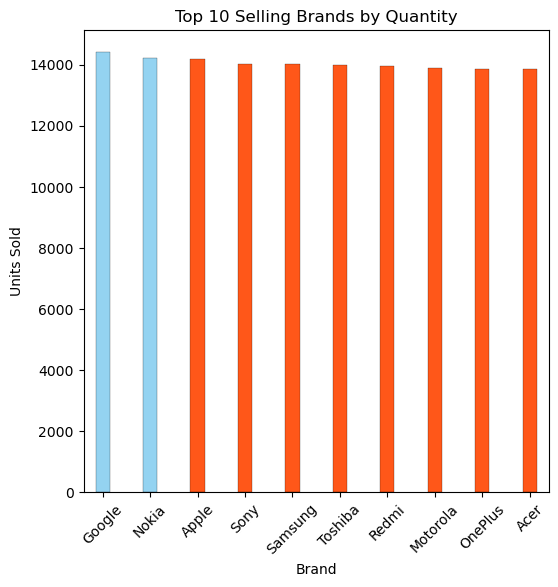

In [20]:
# TOP Brand
plt.figure(figsize=(6,6))

# Creating a color list to help highlight the highest selling 2 
colors_forhighlight = ['#89CFF0', '#89CFF0'] + ['#FF4500'] * 8

brand_byqty.plot(
    kind='bar',
    align='center', 
    width=0.3,
    color=colors_forhighlight, 
    edgecolor='#000000',
    linewidth=0.2, 
    alpha=0.9)


plt.title("Top 10 Selling Brands by Quantity") #title
plt.xlabel("Brand")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show() #visualize

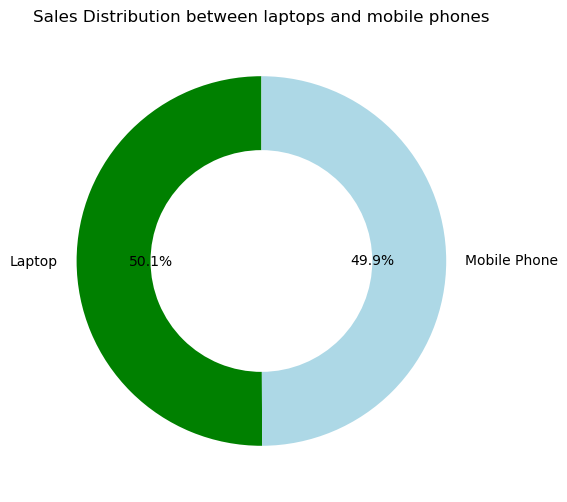

In [21]:
plt.figure(figsize=(6, 6))
top_product.plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['green', 'lightblue'],
    wedgeprops={'width': 0.4} # creating the donut hole
)

plt.title("Sales Distribution between laptops and mobile phones")
plt.ylabel("") 
plt.show()

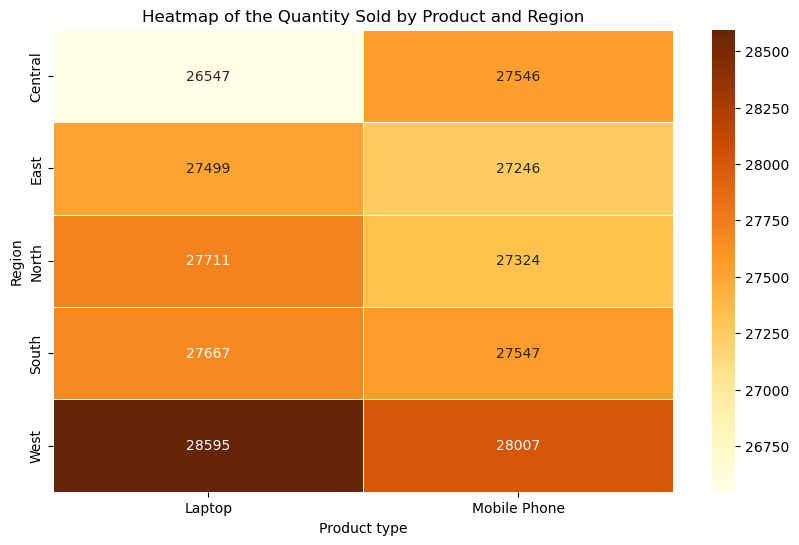

In [23]:
#HEATMAP
# Creating a matrix where Rows are Regions and Columns are Products
# Values = the sum of Quantity
heatmap_data = df.pivot_table(index='Region', columns='Product', values='Quantity Sold', aggfunc='sum')


plt.figure(figsize=(10, 6))

# annot=True for putting the actual numbers inside the squares
# cmap='YlOrBr' for the color
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrBr', linewidths=0.5)

plt.title('Heatmap of the Quantity Sold by Product and Region')
plt.xlabel('Product type')
plt.ylabel('Region')
plt.show()